*   Name: 趙以婷
*   Student ID: 111403534
*   Github Repository: https://github.com/qqqq555/data-science
*   Python Version: 3.12.12
*   requirements.txt:
    ```text
    pandas==2.2.2
    numpy==2.0.2
    matplotlib==3.10.0
    seaborn==0.13.2
    scikit-learn==1.6.1
    ```

## 1. Formalize Project Topic, Motivations, and Data Sources

* **Project Topic:** Volunteer Capacity vs Service Demand in Taiwan’s Long-Term Care (LTC) 2.0 Nutritional Meal Service.
* **Motivations:** As Taiwan rapidly transitions into a super-aged society, the demand for LTC nutritional meal services (Meals-on-Wheels) is growing exponentially. These meals are critical not just for nutrition, but also as daily wellness checks for solitary elders. However, meal delivery heavily relies on the physical capacity of volunteers. This project investigates whether the recruitment of volunteers is keeping pace with the surging service demand across different counties, aiming to identify localized "service bottlenecks" where the volunteer system might face a potential collapse.
* **Data Sources:** 高齡及長期照顧統計專區-長期照顧類 (https://dep.mohw.gov.tw/dos/cp-5223-62358-113.html#_4.%E9%95%B7%E6%9C%9F%E7%85%A7%E9%A1%A7)
  * 4.1.2	長期照顧十年計畫2.0-營養餐飲服務

### Data Loading and Cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# --- 1. Data Loading and Cleaning (Preserving 110 Year) ---
file_path = '4.2+長期照顧十年計畫2.0-營養餐飲服務.xlsx'

# ---------------------------------------------------------
# A. Load Historical Data (110~)
# ---------------------------------------------------------
df_hist_raw = pd.read_excel(file_path, sheet_name='歷年(110~)', header=None)

# Extract relevant columns: Col 0 (Year), Col 1 (Total Demand), Col 25 (Total Volunteers)
hist_data = df_hist_raw.iloc[:, [0, 1, 25]].copy()
hist_data.columns = ['Year', 'Service_Demand', 'Total_Volunteers']

# FILTER: Only keep rows where 'Year' starts with 3 digits followed by '年'
hist_data = hist_data.dropna(subset=['Year'])
hist_data = hist_data[hist_data['Year'].astype(str).str.match(r'^\d{3}年')]

# Extract integer year
hist_data['Year'] = hist_data['Year'].astype(str).str.extract(r'^(\d{3})')[0].astype(int)

# Convert to numeric safely (Government's '…' will become NaN, which is correct for missing data)
hist_data['Service_Demand'] = pd.to_numeric(hist_data['Service_Demand'].astype(str).str.replace(',', ''), errors='coerce')
hist_data['Total_Volunteers'] = pd.to_numeric(hist_data['Total_Volunteers'].astype(str).str.replace(',', ''), errors='coerce')

# Calculate burden rate (NaNs will remain NaN)
hist_data['Burden_Rate'] = hist_data['Service_Demand'] / hist_data['Total_Volunteers']


# ---------------------------------------------------------
# B. Load County-Level Data (Year 113)
# ---------------------------------------------------------
df_113_raw = pd.read_excel(file_path, sheet_name='113', header=None)

# Extract relevant columns
county_data = df_113_raw.iloc[:, [0, 1, 25]].copy()
county_data.columns = ['County', 'Service_Demand', 'Total_Volunteers']

# Clean 'County' column
county_data = county_data.dropna(subset=['County'])
county_data = county_data[~county_data['County'].astype(str).str.contains('總計|區域別|Locality|單位|民國|長期照顧')]

# Remove English text
county_data['County'] = county_data['County'].astype(str).str.replace(r'[a-zA-Z\s]+', '', regex=True).str.strip()

# Convert to numeric
county_data['Service_Demand'] = pd.to_numeric(county_data['Service_Demand'].astype(str).str.replace(',', ''), errors='coerce')
county_data['Total_Volunteers'] = pd.to_numeric(county_data['Total_Volunteers'].astype(str).str.replace(',', ''), errors='coerce')

# Drop any incomplete rows ONLY in county data (we need clean data for K-Means)
county_data = county_data.dropna()

# Calculate burden rate
county_data['Burden_Rate'] = county_data['Service_Demand'] / (county_data['Total_Volunteers'] + 0.0001)

print("Data successfully loaded! (Year 110 volunteer data is intentionally kept as NaN due to official missing records)")
display(hist_data)
display(county_data.head())

Data successfully loaded! (Year 110 volunteer data is intentionally kept as NaN due to official missing records)


,Year,Service_Demand,Total_Volunteers,Burden_Rate
6,110,20544,NaN,NaN
7,111,25745,2706.0,9.514043
8,112,24928,2980.0,8.365101
9,113,24019,2887.0,8.319709


,County,Service_Demand,Total_Volunteers,Burden_Rate
7,新北市,561.0,153.0,3.666664
8,臺北市,1653.0,205.0,8.063411
9,桃園市,1153.0,17.0,67.823130
10,臺中市,4150.0,203.0,20.443340
11,臺南市,1566.0,214.0,7.317754


## 2. Summary statistics

In [ ]:
# --- Summary Statistics ---
print("--- Historical Trend Statistics (Year 110-113) ---")
display(hist_data.describe())

print("\n--- County-Level Burden Statistics (Year 113) ---")
display(county_data[['Service_Demand', 'Total_Volunteers', 'Burden_Rate']].describe())

# Calculate Growth Rates
# Demand growth from 110 to 113
demand_growth = (hist_data['Service_Demand'].iloc[-1] - hist_data['Service_Demand'].iloc[0]) / hist_data['Service_Demand'].iloc[0] * 100

# Volunteer growth from 111 to 113 (since 110 is NaN)
first_valid_vol = hist_data['Total_Volunteers'].dropna().iloc[0]
vol_growth = (hist_data['Total_Volunteers'].iloc[-1] - first_valid_vol) / first_valid_vol * 100

print(f"\n[Key Statistical Findings]")
print(f"* Demand Growth (Year 110-113): {demand_growth:.2f}%")
print(f"* Volunteer Growth (Year 111-113): {vol_growth:.2f}%")
print(f"* The national average burden in Year 113 is {county_data['Burden_Rate'].mean():.2f} elders per volunteer.")

--- Historical Trend Statistics (Year 110-113) ---


,Year,Service_Demand,Total_Volunteers,Burden_Rate
count,4.000000,4.000000,3.000000,3.000000
mean,111.500000,23809.000000,2857.666667,8.732951
std,1.290994,2287.981789,139.335327,0.676826
min,110.000000,20544.000000,2706.000000,8.319709
25%,110.750000,23150.250000,2796.500000,8.342405
50%,111.500000,24473.500000,2887.000000,8.365101
75%,112.250000,25132.250000,2933.500000,8.939572
max,113.000000,25745.000000,2980.000000,9.514043



--- County-Level Burden Statistics (Year 113) ---


,Service_Demand,Total_Volunteers,Burden_Rate
count,22.000000,22.000000,22.000000
mean,1091.772727,131.227273,10.992287
std,1031.814718,140.811232,14.158560
min,0.000000,0.000000,0.000000
25%,319.750000,45.250000,4.462772
50%,879.500000,94.500000,7.571305
75%,1488.750000,151.000000,12.586999
max,4150.000000,639.000000,67.823130



[Key Statistical Findings]
* Demand Growth (Year 110-113): 16.91%
* Volunteer Growth (Year 111-113): 6.69%
* The national average burden in Year 113 is 10.99 elders per volunteer.


## 3. Visualization

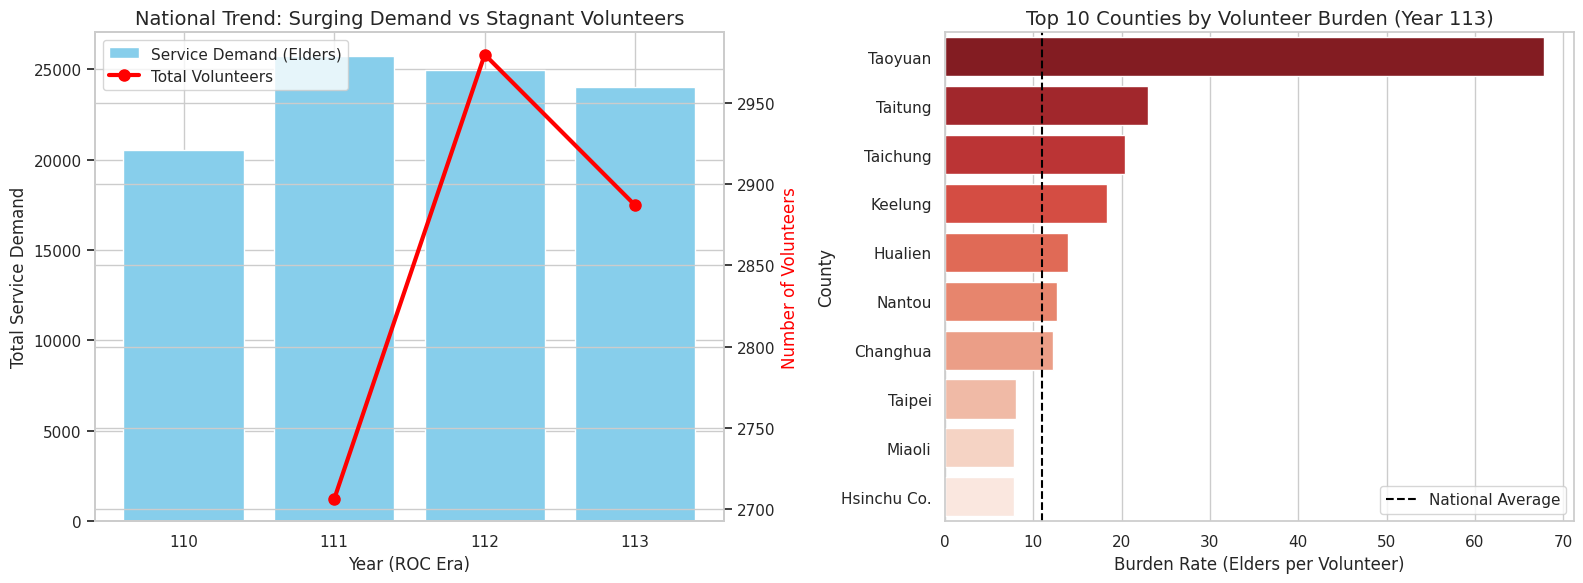

In [ ]:
# --- Visualization ---
# Note: Using standard English fonts to avoid Colab Chinese font rendering issues
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Historical Trend (Dual Axis)
ax1 = axes[0]
ax1.bar(hist_data['Year'].astype(str), hist_data['Service_Demand'], color='skyblue', label='Service Demand (Elders)')
ax1.set_xlabel('Year (ROC Era)', fontsize=12)
ax1.set_ylabel('Total Service Demand', fontsize=12)
ax1.set_title('National Trend: Surging Demand vs Stagnant Volunteers', fontsize=14)

ax2 = ax1.twinx()
ax2.plot(hist_data['Year'].astype(str), hist_data['Total_Volunteers'], color='red', marker='o', linewidth=3, markersize=8, label='Total Volunteers')
ax2.set_ylabel('Number of Volunteers', color='red', fontsize=12)

# Combine Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Plot 2: Top 10 Most Burdened Counties
county_sorted = county_data.sort_values('Burden_Rate', ascending=False).head(10)
# Map Chinese county names to English for visualization safety in standard Colab
county_dict = {'新北市': 'New Taipei', '臺北市': 'Taipei', '桃園市': 'Taoyuan', '臺中市': 'Taichung', '臺南市': 'Tainan', '高雄市': 'Kaohsiung', '新竹縣': 'Hsinchu Co.', '苗栗縣': 'Miaoli', '彰化縣': 'Changhua', '南投縣': 'Nantou', '雲林縣': 'Yunlin', '嘉義縣': 'Chiayi Co.', '屏東縣': 'Pingtung', '宜蘭縣': 'Yilan', '花蓮縣': 'Hualien', '臺東縣': 'Taitung', '澎湖縣': 'Penghu', '基隆市': 'Keelung', '新竹市': 'Hsinchu City', '嘉義市': 'Chiayi City', '金門縣': 'Kinmen', '連江縣': 'Lienchiang'}
county_sorted['County_EN'] = county_sorted['County'].map(county_dict)

sns.barplot(data=county_sorted, x='Burden_Rate', y='County_EN', palette='Reds_r', ax=axes[1])
axes[1].axvline(county_data['Burden_Rate'].mean(), color='black', linestyle='--', label='National Average')
axes[1].set_title('Top 10 Counties by Volunteer Burden (Year 113)', fontsize=14)
axes[1].set_xlabel('Burden Rate (Elders per Volunteer)', fontsize=12)
axes[1].set_ylabel('County', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Statistical Modeling: K-Means Clustering
To provide systematic policy recommendations, I apply **K-Means Clustering** based on the `Service_Demand` and `Total_Volunteers`. This machine learning algorithm segments the 22 counties into distinct structural profiles, allowing us to pinpoint "Resource Deserts"—areas that face systemic collapse due to high demand but critically low volunteer numbers.

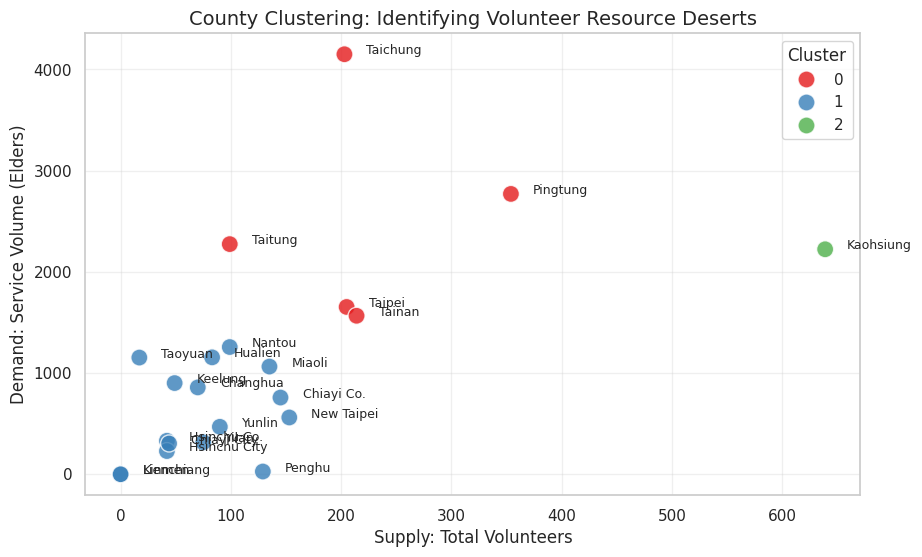

--- Average Capacity by Cluster ---


,Service_Demand,Total_Volunteers,Burden_Rate
Cluster,,,
0,2482.6000,215.0000,13.323807
1,586.4375,73.3125,10.733276
2,2223.0000,639.0000,3.478873


In [ ]:
# --- K-Means Clustering ---
# Select features for clustering
features = county_data[['Total_Volunteers', 'Service_Demand']]

# Standardize the data (crucial for distance-based algorithms)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply K-Means (Segmenting into 3 risk profiles)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
county_data['Cluster'] = kmeans.fit_predict(scaled_features)

# Map Chinese names to English for the plot
county_data['County_EN'] = county_data['County'].map(county_dict)

# Plotting the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=county_data, x='Total_Volunteers', y='Service_Demand', hue='Cluster', palette='Set1', s=150, alpha=0.8)

# Annotate counties
for i in range(county_data.shape[0]):
    plt.text(county_data['Total_Volunteers'].iloc[i] + 20,
             county_data['Service_Demand'].iloc[i],
             county_data['County_EN'].iloc[i], fontsize=9)

plt.title('County Clustering: Identifying Volunteer Resource Deserts', fontsize=14)
plt.xlabel('Supply: Total Volunteers', fontsize=12)
plt.ylabel('Demand: Service Volume (Elders)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Display cluster summary
print("--- Average Capacity by Cluster ---")
cluster_summary = county_data.groupby('Cluster')[['Service_Demand', 'Total_Volunteers', 'Burden_Rate']].mean()
display(cluster_summary)

## 5. Findings and conclusions

* Widening Supply-Demand Gap: From Year 110-113, national demand for LTC nutritional support surged 16.91%, while the volunteer workforce grew only 6.69%. This structural imbalance pushes the national average burden to roughly 11 recipients per volunteer.

* Severe Regional Disparities: Service bottlenecks are highly localized. Taoyuan City faces a critical shortage (67.82 recipients/volunteer), with Taitung, Taichung, and Keelung also showing extreme strain.

* Resource Distribution Profiles (K-Means):

  * Cluster 0 (Resource Deserts): High demand meets low volunteer capacity (e.g., Taipei, Tainan). These areas face the highest risk of systemic burnout (13.32 average burden).

  * Cluster 1 (Volatile/Moderate): Generally lower demand and volunteer numbers, but contains severe individual outliers like Taoyuan.

  * Cluster 2 (Sustainable): Kaohsiung stands alone with balanced scaling, matching high demand with robust volunteer numbers (3.48 average burden).
### Actionable Recommendations:

1. Targeted Relief & Innovation: High-burden zones (Cluster 0 & Taoyuan) must pivot from traditional volunteer reliance to alternative delivery models, such as community partnerships or commercial logistics integrations.

2. Strategic Recruitment: Implement a proactive national strategy to overhaul volunteer engagement, ensuring workforce growth aligns with the rapidly aging demographic.

3. Data-Driven Allocation: Continuously monitor these metrics to identify emerging regional bottlenecks before localized systems collapse.